In [49]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import datetime
import pytz

NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
LDN_tz = pytz.timezone("Europe/London") 
UTC_tz = pytz.timezone("UTC") 

import sys
sys.path.append("../")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
from MDP.STIRFutures.STIRFutureMDP import STIRFutureMDP
from MDP.IRSwaps.BARCHART_STIRF.rl import BARCHART_STIRF_CURVE
from MDP.STIRFutures.BARCHART.BarchartFetcher import BarchartFetcher

from BT.misc import ql_cal_date_range

In [51]:
bc_stirf_curve = BARCHART_STIRF_CURVE()
stirf_mdp = STIRFutureMDP(source="BARCHART_TOS_LIVE_STIRF-RL")

In [58]:
# ts = NY_tz.localize(datetime.datetime(2026, 2, 17, 17, 00))
# curve, solver = bc_stirf_curve.build_curve(curve_name="USD-OIS-Q8xM12", timestamp=ts, kwargs=dict(force_refresh=False))
# curve, solver = bc_stirf_curve.build_curve(curve_name="USD-SOFR-1D-Q12x3", timestamp=ts, kwargs=dict(force_refresh=True))

# timestamps = ql_cal_date_range(
#     ql.UnitedStates(ql.UnitedStates.GovernmentBond),
#     start=NY_tz.localize(datetime.datetime(2026, 2, 17, 1, 50)),
#     end=NY_tz.localize(datetime.datetime(2026, 2, 17, 17, 00)),
#     freq="1min",
# )
# timestamps = pd.date_range(NY_tz.localize(datetime.datetime(2026, 2, 17, 16, 50)), NY_tz.localize(datetime.datetime(2026, 2, 17, 17, 00)), freq="1min").to_list()

curves = bc_stirf_curve.build_curve(
    curve_name="EUR-EURIBOR-ICE-Q12STIRT",
    timestamp=LDN_tz.localize(datetime.datetime(2026, 2, 19, 17, 00)),
    kwargs={"force_refresh": True},
)
curves 

FETCHING SESSION TOKENS...: 100%|██████████| 13/13 [00:01<00:00,  9.33it/s]


SUCCESS: `conv_tol` reached after 4 iterations (levenberg_marquardt), `f_val`: 0.0071773396185088965, `time`: 0.0188s


<rl.Curve:EUR-EURIBOR-3M at 0x1eccfab5250>

(<Figure size 1200x800 with 1 Axes>,
 <Axes: >,
 [<matplotlib.lines.Line2D at 0x1ecd0627b10>])

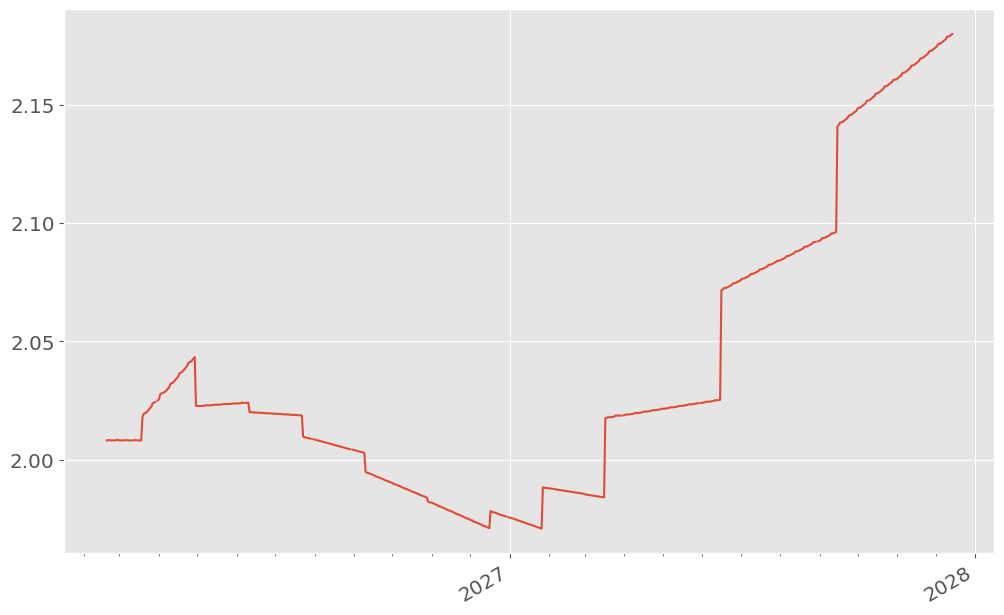

In [59]:
curves.plot("1d")

In [60]:
fomc_dated_ois = {
    "mar26": (rl.dt(2026, 3, 18), rl.dt(2026, 4, 29)),
    "apr26": (rl.dt(2026, 4, 29), rl.dt(2026, 6, 17)),
    "jun26": (rl.dt(2026, 6, 17), rl.dt(2026, 7, 29)),
    "jul26": (rl.dt(2026, 7, 29), rl.dt(2026, 9, 16)),
    "sep26": (rl.dt(2026, 9, 16), rl.dt(2026, 10, 28)),
    "oct26": (rl.dt(2026, 10, 28), rl.dt(2026, 12, 9)),
    # "dec26": (rl.dt(2026, 12, 9), rl.dt(2027, 1, 27)),
}

ecb_dated_ois = {
    "mar26": (rl.dt(2026, 3, 25), rl.dt(2026, 5, 6)),
    "may26": (rl.dt(2026, 5, 6),  rl.dt(2026, 6, 17)),
    "jun26": (rl.dt(2026, 6, 17), rl.dt(2026, 7, 29)),
    "jul26": (rl.dt(2026, 7, 29), rl.dt(2026, 9, 16)),
    "sep26": (rl.dt(2026, 9, 16), rl.dt(2026, 11, 4)),
    "nov26": (rl.dt(2026, 11, 4), rl.dt(2026, 12, 23)),
}


def build_fomc_ois(meeting: str, rl_curve: rl.Curve, risk=None, notional=None, rl_irs_swap_kargs={}):
    assert risk is not None or notional is not None, "Must pass in `risk` or `notional`"

    if risk is not None:
        unit_delta = rl.IRS(
            effective=fomc_dated_ois[meeting][0], termination=fomc_dated_ois[meeting][1], spec="usd_irs_lt_2y", curves=rl_curve, notional=1
        ).analytic_delta(rl_curve)
        notional = risk / unit_delta

    fomc_swap = rl.IRS(
        effective=fomc_dated_ois[meeting][0], termination=fomc_dated_ois[meeting][1], spec="usd_irs_lt_2y", curves=rl_curve, notional=notional, **rl_irs_swap_kargs
    )
    return fomc_swap

def build_ecb_ois(meeting: str, rl_curve: rl.Curve, risk=None, notional=None, rl_irs_swap_kargs={}):
    assert risk is not None or notional is not None, "Must pass in `risk` or `notional`"

    if risk is not None:
        unit_delta = rl.IRS(
            effective=ecb_dated_ois[meeting][0], termination=ecb_dated_ois[meeting][1], spec="eur_irs", curves=rl_curve, notional=1
        ).analytic_delta(rl_curve)
        notional = risk / unit_delta

    ecb_swap = rl.IRS(
        effective=ecb_dated_ois[meeting][0], termination=ecb_dated_ois[meeting][1], spec="eur_irs", curves=rl_curve, notional=notional, **rl_irs_swap_kargs
    )
    return ecb_swap 


# for key in fomc_dated_ois.keys():
#     print(key, build_fomc_ois(meeting=key, rl_curve=curves, notional=1).rate().real)

for key in ecb_dated_ois.keys():
    print(key, build_ecb_ois(meeting=key, rl_curve=curves, notional=1).rate().real)

mar26 2.0334668773819966
may26 2.0252585573222435
jun26 2.0202324100337954
jul26 2.007006059427591
sep26 1.9906704414740517
nov26 1.9789476378689321


In [102]:
mdp = STIRFutureMDP(source="BARCHART_STIRF-RL")

# must be timezone-aware
chi_tz = pytz.timezone("America/Chicago")
ts = chi_tz.localize(datetime.datetime(2026, 2, 20, 17, 00))

mdp.get_data(
    {
        "symbols": ["SERCM1"],
        "timestamp": ts,
        "force_refresh": True,
        "cache_full_intraday_fetch": True,
    }
)

FETCHING SESSION TOKENS...: 100%|██████████| 2/2 [00:01<00:00,  1.80it/s]


{'SERCM1': [RLSTIRFuturePricer(_curve='USD-SOFR-1D', _rl_stirf_id='SR1G26', _reference_date=datetime.date(2026, 2, 20), _effective_date=datetime.date(2026, 2, 2), _maturity_date=datetime.date(2026, 3, 2), _price=96.335, _rate=3.6650000000000063, _contracts=1, _notional=1000000, _meta_data={'symbol': 'SR1G26', 'price': 96.335, 'timestamp': '2026-02-20T23:00:00+00:00', 'schema': 1, 'fixings': USD-SOFR-1D
  2018-04-02    1.80
  2018-04-03    1.83
  2018-04-04    1.74
  2018-04-05    1.75
  2018-04-06    1.75
                ... 
  2026-02-12    3.65
  2026-02-13    3.66
  2026-02-17    3.71
  2026-02-18    3.73
  2026-02-19    3.67
  Name: Fixing, Length: 1969, dtype: float64})]}

In [50]:
# bcf = BarchartFetcher()

# ticker = "RGZ26"

# df = bcf.barchart_timeseries_api(
#     barchart_symbols=[ticker],
#     start_date=NY_tz.localize(datetime.datetime(2026, 2, 17, 7, 00)),
#     end_date=NY_tz.localize(datetime.datetime(2026, 2, 17, 17, 00)),
#     interval=1,
# )[ticker]

# df